In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo
#import pyrtlib as rtl
import time

import atmo3 as a3


In [2]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 128]
box_length = [22000., 22000., 11000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 10, 4, 17, 0, tzinfo=timezone.utc) #day with clouds

t0 = time.perf_counter()
# =============================================================================
# Scan strategy
# =============================================================================

# dt = 0 case
timesamples = [np.datetime64(time_utc)]
az          = [0.]      # in deg
el          = [45.]     # in deg

# remaining 300 samples
for sample in range(300-1):
    timesamples.append(timesamples[-1] + np.timedelta64(200, 'ms'))
    az.append(az[-1] + 0.2)
    el.append(el[-1]) 
    
t1 = time.perf_counter()

print(f"Scan setup time : {t1 - t0:.6f} s")

Scan setup time : 0.002879 s


/tmp/ipykernel_378684/3043497214.py:29: UserWarning: no explicit representation of timezones available for np.datetime64
  timesamples = [np.datetime64(time_utc)]


In [3]:
# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for October 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

northwindfile = f'{atmo3_data}era5/2023/v.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # V-component North wind
eastwindfile  = f'{atmo3_data}era5/2023/u.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # U-component East wind

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

# =============================================================================
# Initialise the atmosphere object
# ERA5 profiles are read and interpolated to the site location; profiles are
# then normalised so that the ground-level temperature and column-integrated
# PWV match the mean APEX observations recorded within ±30 min of time_utc.
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)



obs = a3.Observer(
    grid_wsp = atmo_box.grid_wsp,
    super_grid = atmo_box.super_grid,
    northwind_era5_file = None,
    eastwind_era5_file = None,
    boresight = jnp.array(boresight),       # in grid coordinates
    passband = passband, 
    fwhm_arcmin = fwhm
)

obs.compute_los_for_scan(timesamples, az, el)



obs_w = a3.Observer(
    grid_wsp = atmo_box.grid_wsp,
    super_grid = atmo_box.super_grid,
    northwind_era5_file = northwindfile,
    eastwind_era5_file = eastwindfile,
    boresight = jnp.array(boresight),       # in grid coordinates
    passband = passband, 
    fwhm_arcmin = fwhm
)

obs_w.compute_los_for_scan(timesamples, az, el)

0.70672131147541 0.07471548950240973


In [4]:
k_array = np.arange(4*nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}

atmo_box.add_temperature(
    power_spec=pspec_ta
)

# Water-vapour mass-density fluctuation field (units: kg/m³).
# Scaling profile: 0.1 % of ERA5 specific-humidity mean × q→ρ conversion.
atmo_box.add_watervapor(
    power_spec=pspec_q
)

atmo_box.generate_realization(time_step=0)


Random field : 29.807318 s
Apply P(k) : 0.846554 s
IRFFT : 0.021090 s
Rescaled field : 0.502815 s
Random field : 9.992571 s
Apply P(k) : 10.560183 s
IRFFT : 0.070305 s
Rescaled field : 0.284612 s


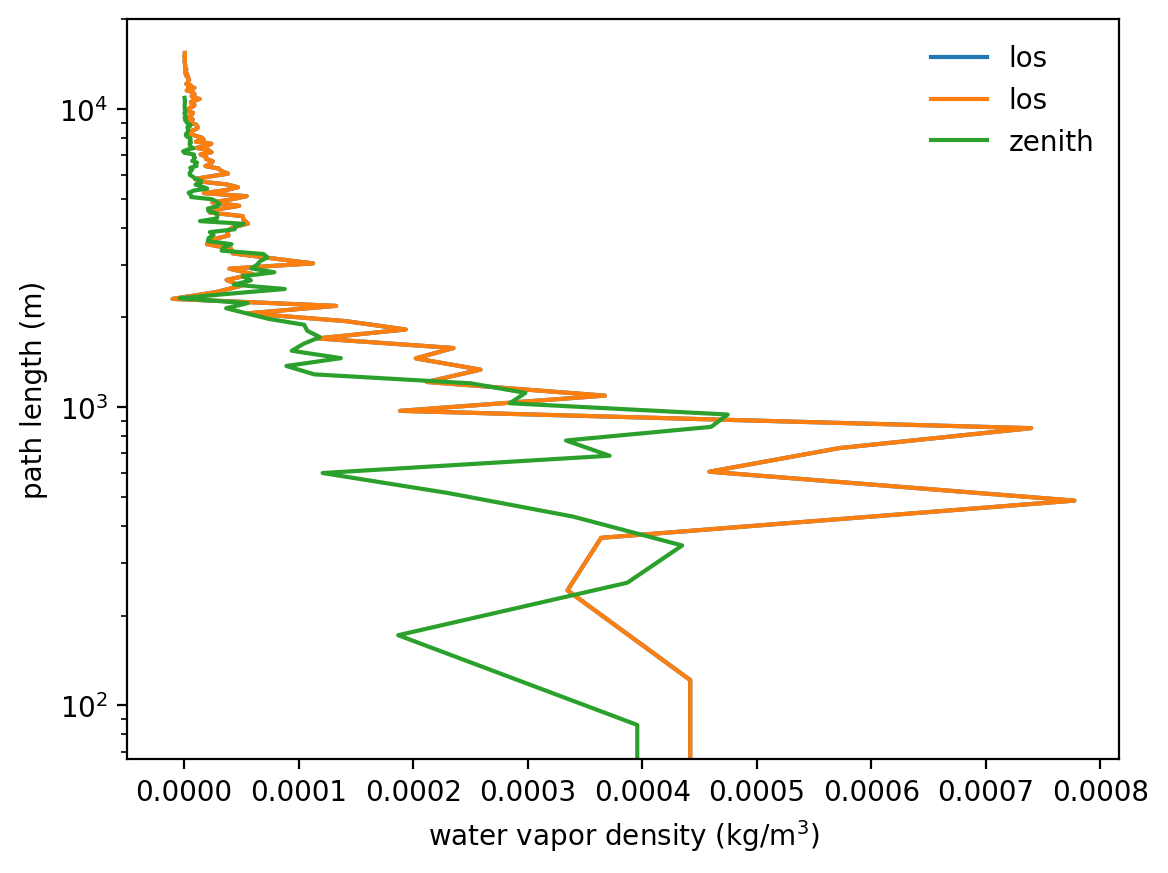

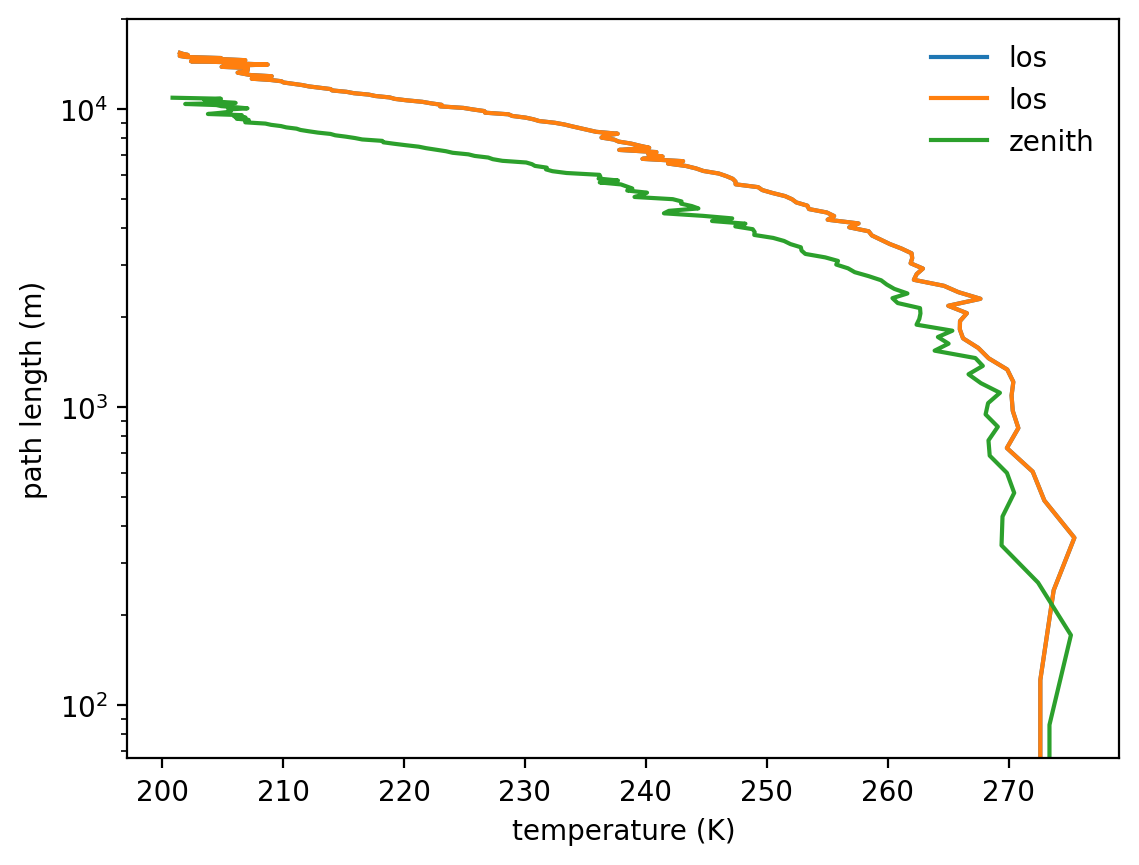

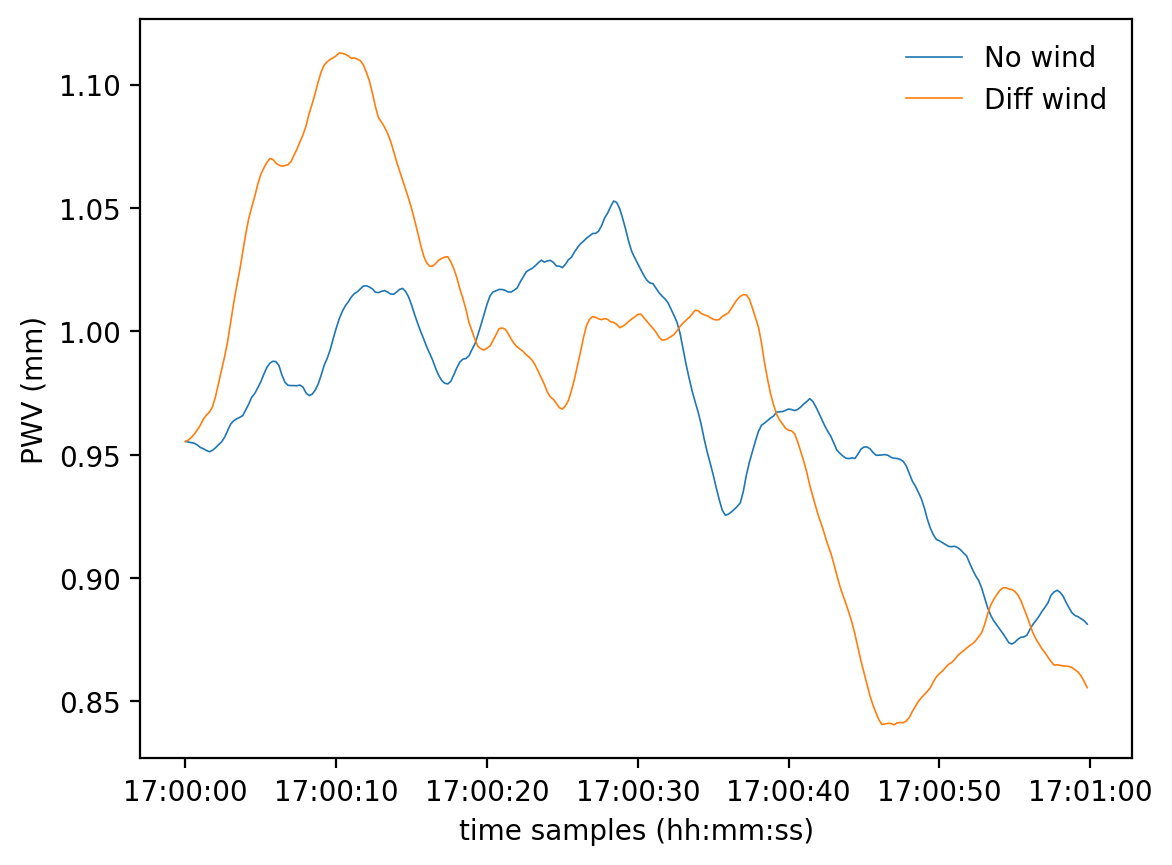

In [5]:

water_vapor_los = obs.scan_component(atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))


temperature_los = obs.scan_component(atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))

water_vapor_los_w = obs_w.scan_component(atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))
temperature_los_w = obs_w.scan_component(atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))

pwv_scan   = jnp.trapezoid(water_vapor_los,   x=obs.los_obj[:,:,3], axis=1)
pwv_scan_w = jnp.trapezoid(water_vapor_los_w, x=obs.los_obj[:,:,3], axis=1)

plt.figure(dpi=200)
plt.plot(water_vapor_los[0], obs.los_obj[0,:,3], label='los')
plt.plot(water_vapor_los[0], obs_w.los_obj[0,:,3], label='los')
plt.plot((atmo_box.components['water vapor'].field + atmo_box.component_mean['water vapor']['f'].reshape(1, 1, -1))[nside_grid[0]//2, nside_grid[1]//2], atmo_box.grid_wsp.grid_axis(axis=2), label='zenith')
plt.yscale('log')
plt.xlabel(r"water vapor density (kg/m${}^3$)")
plt.ylabel("path length (m)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(temperature_los[0], obs.los_obj[0,:,3], label='los')
plt.plot(temperature_los_w[0], obs_w.los_obj[0,:,3], label='los')
plt.plot((atmo_box.components['temperature'].field + atmo_box.component_mean['temperature']['f'].reshape(1, 1, -1))[nside_grid[0]//2, nside_grid[1]//2], atmo_box.grid_wsp.grid_axis(axis=2), label='zenith')
plt.yscale('log')
plt.xlabel(r"temperature (K)")
plt.ylabel("path length (m)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, pwv_scan,   '-', lw=0.6, label='No wind')
plt.plot(timesamples, pwv_scan_w, '-', lw=0.6, label='Diff wind')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel("PWV (mm)")
plt.legend(frameon=False)
plt.show()
plt.close()

In [6]:
pressure_los = jnp.interp(obs.los_obj[:,:,2], obs.axes[2], atmo_box.atm_calibrator.pressure) 
pressure_los_w = jnp.interp(obs_w.los_obj[:,:,2], obs_w.axes[2], atmo_box.atm_calibrator.pressure)
freqs_GHz = jnp.array([ 150. , 185.])

I_atm = a3.get_emission(temperature_los, pressure_los, water_vapor_los, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_atm = a3.intensitySI_to_Tb(I_atm[:,:,None], freqs_GHz[None, None,:])[:,:,0]

I_atm_w = a3.get_emission(temperature_los_w, pressure_los, water_vapor_los_w, jnp.diff(obs_w.los_obj[:,:,3], axis=1, prepend=0), freqs_GHz)
T_atm_w = a3.intensitySI_to_Tb(I_atm_w[:,:,None], freqs_GHz[None, None,:])[:,:,0]

Let's now add the clouds

In [7]:
ccfile = f'{atmo3_data}era5/2023/cc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile = f'{atmo3_data}era5/2023/ciwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile = f'{atmo3_data}era5/2023/clwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'



cubes_ice_liquid = atmo_box.derive_liquid_ice_cubes(ccfile = ccfile, ciwcfile=ciwcfile, clwcfile=clwcfile)

Notice: No cloud liquid water found in the profile. Liquid cube will not be generated.


In [9]:
iwc_los = obs.scan_component(cubes_ice_liquid['ice'])
iwc_los_w = obs_w.scan_component(cubes_ice_liquid['ice'])

#lwc_los = obs.scan_component(cubes_ice_liquid['liquid'])
#lwc_los_w = obs_w.scan_component(cubes_ice_liquid['liquid'])

from atmo3 import constants

rho_air_los = pressure_los / (constants.R_dry_air * temperature_los)
rho_air_los_w = pressure_los_w / (constants.R_dry_air * temperature_los_w)


IWP_scan   = jnp.trapezoid(rho_air_los*iwc_los,   x=obs.los_obj[:,:,3], axis=1)
IWP_scan_w = jnp.trapezoid(rho_air_los_w*iwc_los_w, x=obs.los_obj[:,:,3], axis=1)
#LWP_scan   = jnp.trapezoid(rho_air_los*lwc_los,   x=obs.los_obj[:,:,3], axis=1)
#LWP_scan_w = jnp.trapezoid(rho_air_los_w*lwc_los_w, x=obs.los_obj[:,:,3], axis=1)

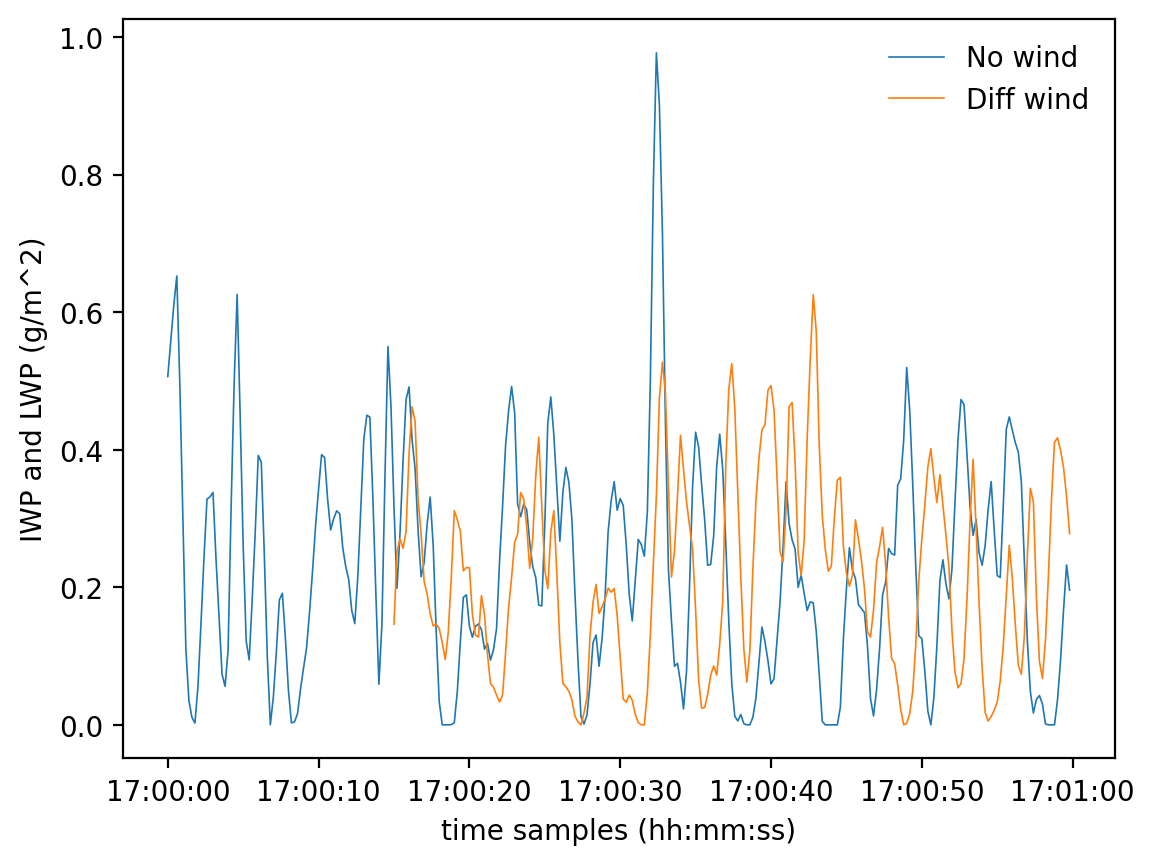

In [10]:
plt.figure(dpi=200)
plt.plot(timesamples, IWP_scan*1e3,   '-', lw=0.6, label='No wind')
plt.plot(timesamples, IWP_scan_w*1e3, '-', lw=0.6, label='Diff wind')
#plt.plot(timesamples, LWP_scan*1e3,   '--', lw=0.6, label='No wind')
#plt.plot(timesamples, LWP_scan_w*1e3, '--', lw=0.6, label='Diff wind')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel("IWP and LWP (g/m^2)")
plt.legend(frameon=False)
plt.show()
plt.close()

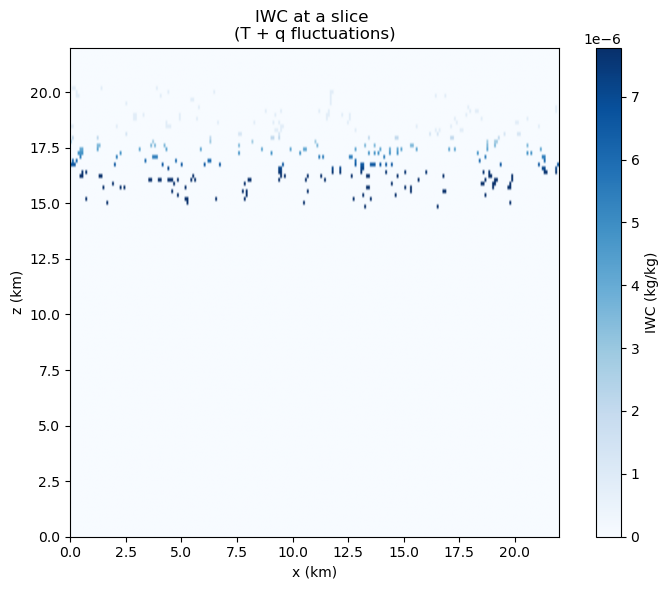

In [11]:
#Let's look inside the cubes of ice and liquid, we don't consider the scan here, just the box with cubes_ice_liquid['ice'] and cubes_ice_liquid['liquid']

# Let's do a xz slice through the middle of the box
# Extract the 2D slice from the newly generated cloud mask
iwc_slice = cubes_ice_liquid['ice'][:, nside_grid[1]//2, :]

plt.figure(figsize=(8,6))
plt.imshow(iwc_slice.T, origin='lower', cmap='Blues',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'IWC at a slice \n(T + q fluctuations)')
plt.colorbar(label='IWC (kg/kg)')
plt.xlabel('x (km)')
plt.ylabel('z (km)')
plt.tight_layout()
plt.show()

In [12]:
import jax.numpy as jnp
import xarray as xr
from atmo3 import atm_utils

def get_full_atmospheric_column(atmosphere, temp_era5_file, q_era5_file, dz=10.0):
    """
    Extracts the full atmospheric column from ERA5 data starting exactly at the 
    ground (site_altitude) and going up to the top of the ERA5 pressure levels.
    
    Parameters
    ----------
    atmosphere : Atmosphere
        The initialized atmo3 Atmosphere object.
    temp_era5_file : str
        Path to the ERA5 temperature NetCDF file.
    q_era5_file : str
        Path to the ERA5 specific humidity NetCDF file.
    dz : float
        The vertical resolution (in meters) for the new smoothed 1D grid.
        
    Returns
    -------
    T_full : jnp.ndarray
        Temperature profile (K).
    P_full : jnp.ndarray
        Pressure profile (Pa).
    rho_w_full : jnp.ndarray
        Water vapor density profile (kg/m^3).
    dz_full : jnp.ndarray
        Array of dz steps (m).
    """
    sg = atmosphere.super_grid
    
    # 1. Define the full vertical grid from ground to the top of ERA5
    max_era5_altitude = sg.zgeo_atsite[-1]
    z_full = jnp.arange(atmosphere.site_altitude, max_era5_altitude, dz)
    dz_full = jnp.full_like(z_full, dz)
    
    # 2. Interpolate the full pressure profile
    P_full = jnp.interp(z_full, sg.zgeo_atsite, sg.plev, left='extrapolate', right='extrapolate')
    
    # 3. Helper to extract raw full profiles from NetCDF (similar to sg.era5_interp2site)
    time_str = f'{sg.time_utc[0]:%Y-%m-%dT%H:%M:%S}'
    lat, lon = sg.site_coordinates[1], sg.site_coordinates[0] + 360.0
    
    def extract_raw_profile(filepath):
        dataset = xr.open_dataarray(filepath)
        raw_prof = jnp.asarray(dataset.sel(time=time_str).interp(latitude=lat, longitude=lon))[::-1]
        return raw_prof
    
    # 4. Extract and interpolate Temperature and Specific Humidity
    T_raw = extract_raw_profile(temp_era5_file)
    q_raw = extract_raw_profile(q_era5_file)
    
    T_full = jnp.interp(z_full, sg.zgeo_atsite, T_raw, left='extrapolate', right='extrapolate')
    q_full = jnp.interp(z_full, sg.zgeo_atsite, q_raw, left='extrapolate', right='extrapolate')
    
    # 5. Convert Specific Humidity (q) to Water Vapor Density (rho_w)
    T_v_full = atm_utils.virtual_temperature(T_full, q_full)
    rho_w_full = atm_utils.water_vapor_density(q_full, P_full, T_v_full)
    
    return T_full, P_full, rho_w_full, dz_full, z_full

In [13]:
# 1. Get the full continuous profile starting at the APEX telescope
T_f, P_f, rho_w_f, dz_f, z_f = get_full_atmospheric_column(
    atmo_box, 
    tempfile, 
    spechfile, 
    dz=10.0
)


# 2. Compute the cumulative zenith opacity for the whole atmosphere
tau_zenith_1D = a3.compute_tau_zenith(T_f, P_f, rho_w_f, dz_f, freqs_GHz)

# 3. tau_total_zenith is simply the very top value of this integrated column!
tau_total_zenith = tau_zenith_1D[-1, :]

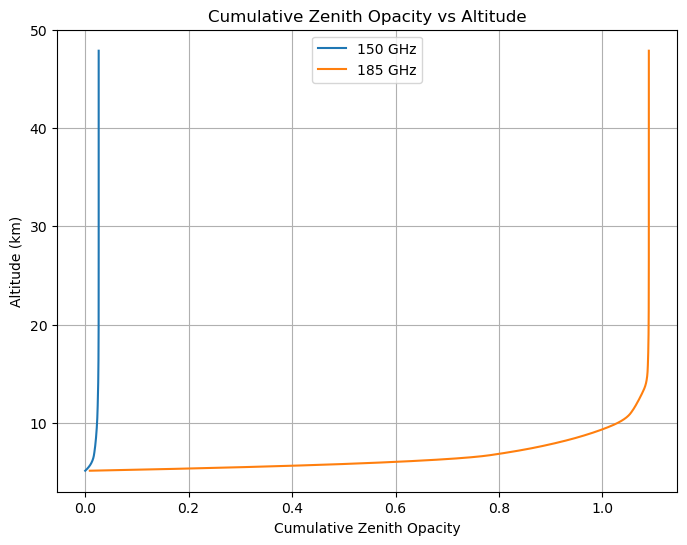

In [14]:
plt.figure(figsize=(8,6))
plt.plot(tau_zenith_1D[:, 0], z_f/1000, label='150 GHz')
plt.plot(tau_zenith_1D[:, 1], z_f/1000, label='185 GHz')
plt.xlabel('Cumulative Zenith Opacity')
plt.ylabel('Altitude (km)')
plt.title('Cumulative Zenith Opacity vs Altitude')
plt.legend()
plt.grid()
plt.show()

In [15]:
z_los = obs.los_obj[:,:,2]
print(z_los.shape)

(300, 128)


In [ ]:
print(z_los)

print(obs.los_obj[:,:,3])

[[ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]
 [ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]
 [ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]
 ...
 [ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]
 [ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]
 [ 5100.     5178.125  5256.25  ... 14865.625 14943.75  15021.875]]
[[    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.65018917]
 [    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.65018917]
 [    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.65018917]
 ...
 [    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.65018917]
 [    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.65018917]
 [    0.           110.48543456   220.97086912 ... 13810.67932005
  13921.16475461 14031.650

In [16]:
tau_los_freq_first = jax.vmap(lambda t: jnp.interp(z_los, z_f, t), in_axes=1)(tau_zenith_1D)

# 6. Transpose the output from (Nf, n_scans, n_los) to the required (n_scans, Nf, n_los)
tau_zenith_los = jnp.transpose(tau_los_freq_first, (1, 0, 2))

In [17]:
#Let's calculate the brightness temperature from ice_crystals

r_eq = 30e-6  # effective radius of ice crystals in metres
V = 4/3 * jnp.pi * r_eq**3  # volume of an ice crystal in m^3
m = 0.5 #aspect ratio of ice crystals, assumed to be oblate spheroids
elevation = el[0]

rho_ice = 917.0  # density of ice in kg/m^3
ice_density_los = iwc_los*rho_air_los/(rho_ice*V) 
ice_density_los_w = iwc_los_w*rho_air_los_w/(rho_ice*V)

B_nu_I_emission, B_nu_Q_emission = a3.get_ice_emission(temperature_los, ice_density_los, r_eq, tau_zenith_los, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), 
                                     freqs_GHz, m, elevation)

B_nu_I_w_emission, B_nu_Q_w_emission = a3.get_ice_emission(temperature_los_w, ice_density_los_w, r_eq, tau_zenith_los, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), 
                                     freqs_GHz, m, elevation)

In [18]:
I_atm_emission = a3.intensitySI_to_Tb(B_nu_I_emission[:,:,None], freqs_GHz[None, None,:])[:,:,0]
Q_atm_emission = a3.intensitySI_to_Tb(B_nu_Q_emission[:,:,None], freqs_GHz[None, None,:])[:,:,0]
I_atm_w_emission = a3.intensitySI_to_Tb(B_nu_I_w_emission[:,:,None], freqs_GHz[None, None,:])[:,:,0]
Q_atm_w_emission = a3.intensitySI_to_Tb(B_nu_Q_w_emission[:,:,None], freqs_GHz[None, None,:])[:,:,0]

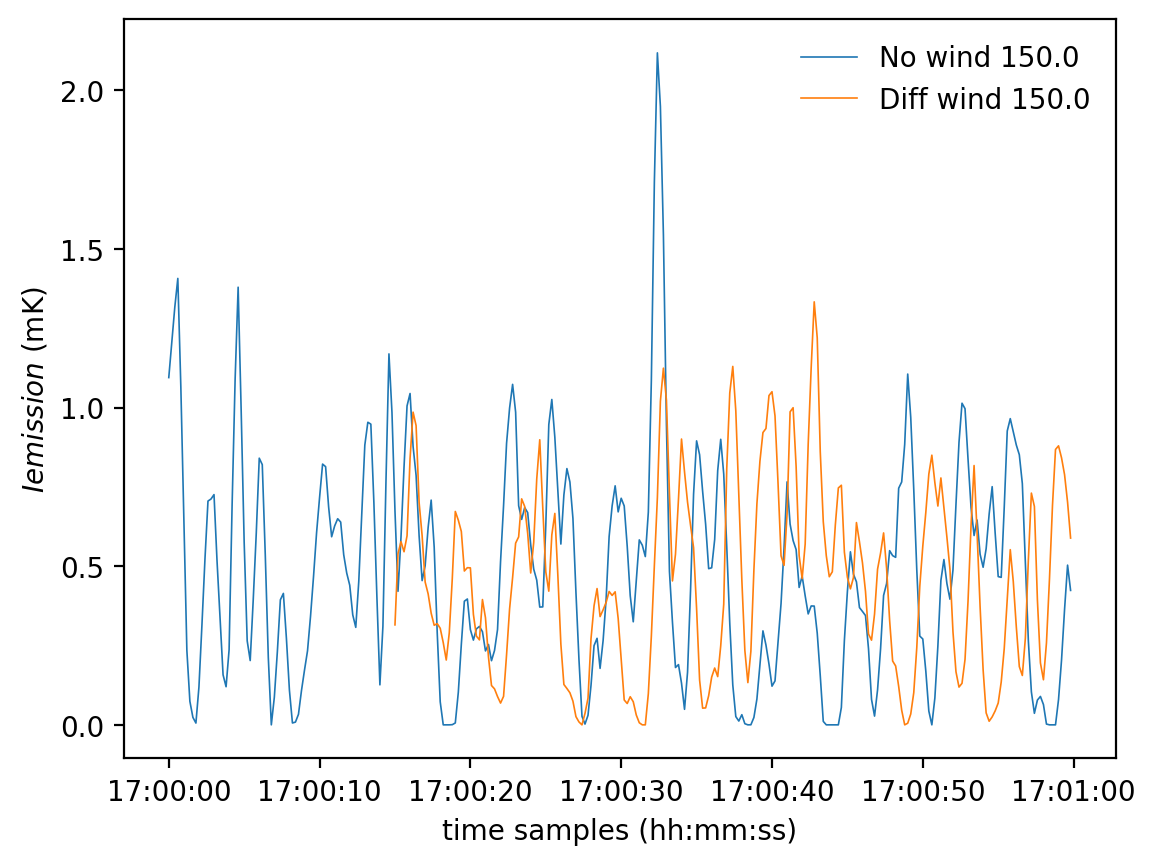

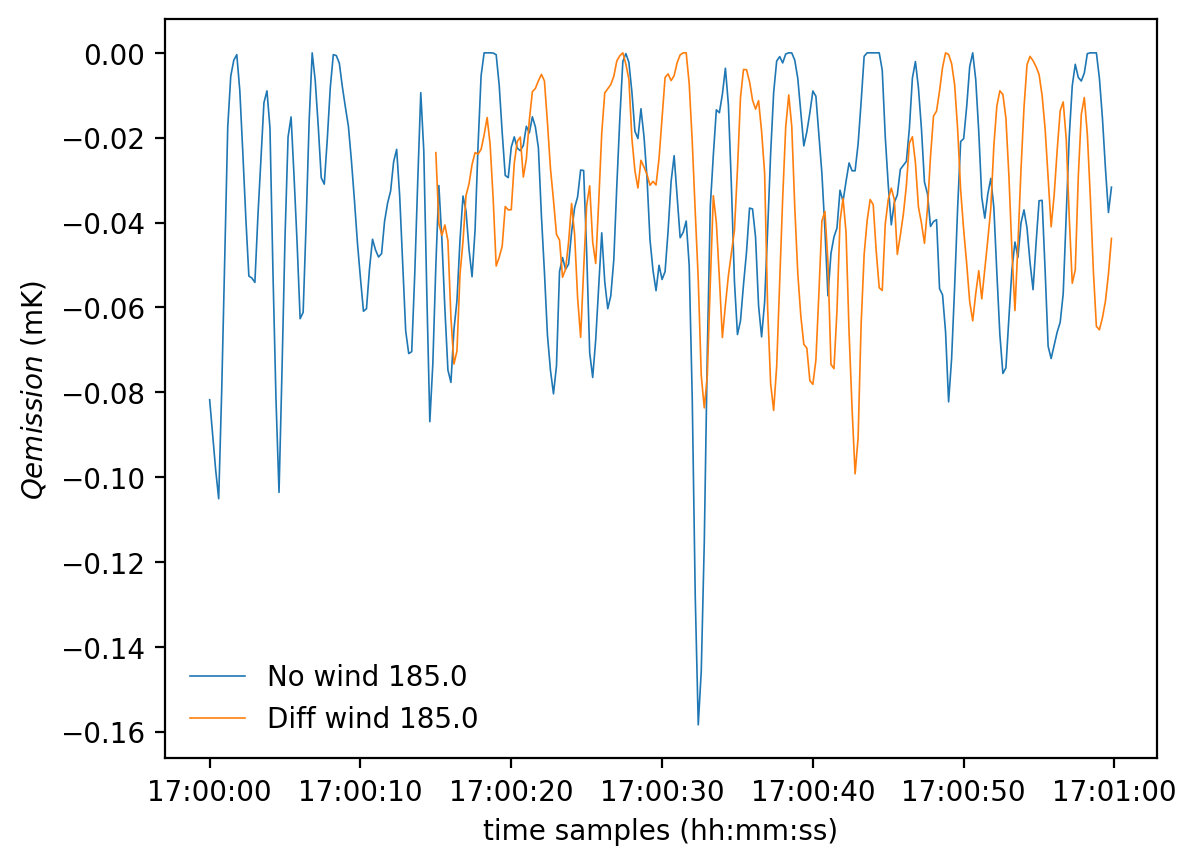

In [19]:
plt.figure(dpi=200)
plt.plot(timesamples, I_atm_emission[:,0]*1e3,   '-', lw=0.6, label=f'No wind {freqs_GHz[0]}')
plt.plot(timesamples, I_atm_w_emission[:,0]*1e3, '-', lw=0.6, label=f'Diff wind {freqs_GHz[0]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$I emission$ (mK)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, Q_atm_emission[:,1]*1e3,   '-', lw=0.6, label=f'No wind {freqs_GHz[1]}')
plt.plot(timesamples, Q_atm_w_emission[:,1]*1e3, '-', lw=0.6, label=f'Diff wind {freqs_GHz[1]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$Q emission$ (mK)")
plt.legend(frameon=False)
plt.show()
plt.close()

In [20]:
B_nu_I_scatter, B_nu_Q_scatter = a3.get_ice_scattering(temperature_los, ice_density_los, r_eq, jnp.diff(obs.los_obj[:,:,3], axis=1, prepend=0), 
                                     freqs_GHz, m, elevation, tau_zenith_los, tau_total_zenith[None, :, None])
B_nu_I_w_scatter, B_nu_Q_w_scatter = a3.get_ice_scattering(temperature_los_w, ice_density_los_w, r_eq, jnp.diff(obs_w.los_obj[:,:,3], axis=1, prepend=0), 
                                     freqs_GHz, m, elevation, tau_zenith_los, tau_total_zenith[None, :, None])

I_atm_scatter = a3.intensitySI_to_Tb(B_nu_I_scatter[:,:,None], freqs_GHz[None, None,:])[:,:,0]
Q_atm_scatter = a3.intensitySI_to_Tb(B_nu_Q_scatter[:,:,None], freqs_GHz[None, None,:])[:,:,0]
I_atm_w_scatter = a3.intensitySI_to_Tb(B_nu_I_w_scatter[:,:,None], freqs_GHz[None, None,:])[:,:,0]
Q_atm_w_scatter = a3.intensitySI_to_Tb(B_nu_Q_w_scatter[:,:,None], freqs_GHz[None, None,:])[:,:,0]



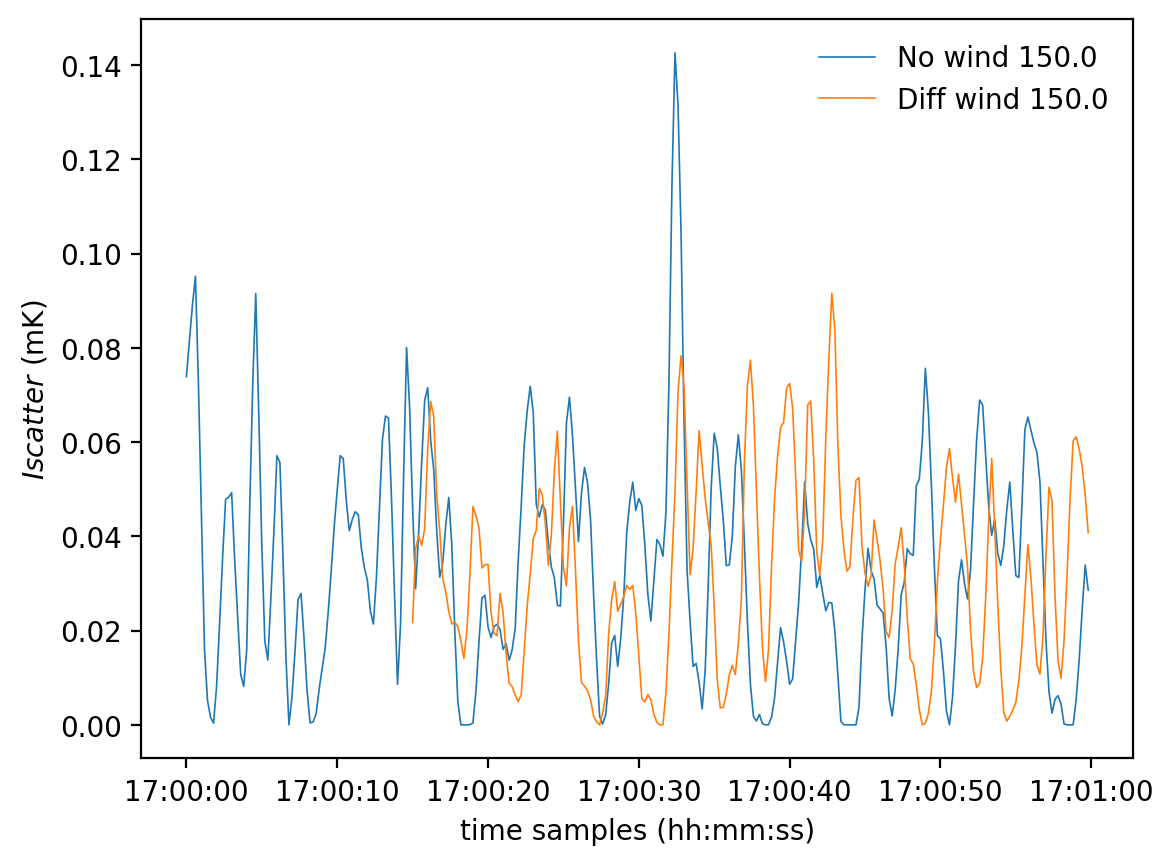

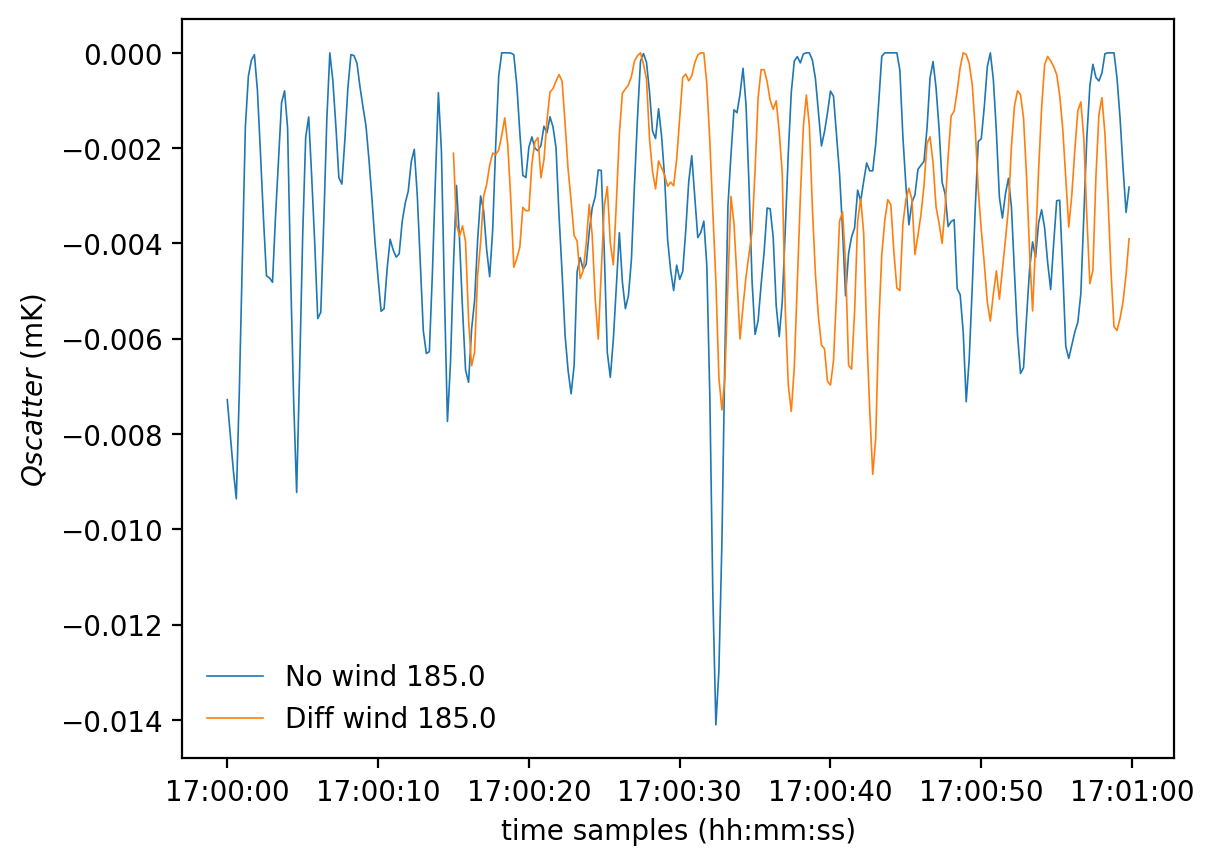

In [21]:
plt.figure(dpi=200)
plt.plot(timesamples, I_atm_scatter[:,0]*1e3,   '-', lw=0.6, label=f'No wind {freqs_GHz[0]}')
plt.plot(timesamples, I_atm_w_scatter[:,0]*1e3, '-', lw=0.6, label=f'Diff wind {freqs_GHz[0]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$I scatter$ (mK)")
plt.legend(frameon=False)
plt.show()
plt.close()

plt.figure(dpi=200)
plt.plot(timesamples, Q_atm_scatter[:,1]*1e3,   '-', lw=0.6, label=f'No wind {freqs_GHz[1]}')
plt.plot(timesamples, Q_atm_w_scatter[:,1]*1e3, '-', lw=0.6, label=f'Diff wind {freqs_GHz[1]}')
# plt.axhline(y=atmo_box.atm_calibrator.apex_pwv_mean)
plt.xlabel("time samples (hh:mm:ss)")
plt.ylabel(r"$Q scatter$ (mK)")
plt.legend(frameon=False)
plt.show()
plt.close()

In [ ]:
print(tau_total_zenith)

[0.03928998 1.70524746]
